In [1]:
from scipy.io import loadmat
import os
from contact_mapper import ContactMapper
from protein_representation import ProteinCollection
from data_scaler import BayesScaler

from utility import parse_matlab_mutation_file, parse_mutations, convert_graph_from_matlab_file
from utility import convert_aa_sequence, preprocess_observations

import numpy as np

In [2]:
!dir .\pdb

 Volume in drive C is Windows
 Volume Serial Number is A079-5C77

 Directory of C:\pro_tooling\pdb

16/01/2021  10.36    <DIR>          .
16/01/2021  10.36    <DIR>          ..
16/01/2021  10.36           264.789 1bni.pdb
16/01/2021  10.28            82.215 1bpi.pdb
16/01/2021  10.26           167.832 1bvc.pdb
16/01/2021  10.26            70.794 1csp.pdb
16/01/2021  10.25           262.764 1lzi.pdb
12/01/2021  17.16            58.968 1pga.pdb
16/01/2021  10.27           164.025 1pin.pdb
16/01/2021  10.27           557.604 1rgg.pdb
16/01/2021  10.27           244.701 1rn1.pdb
16/01/2021  10.27           134.298 1rtb.pdb
16/01/2021  10.36            96.876 1vqb.pdb
16/01/2021  10.25            79.137 2ci2.pdb
16/01/2021  10.25           149.607 2lzm.pdb
16/01/2021  10.26           149.688 2rn2.pdb
16/01/2021  10.27           133.812 4lyz.pdb
              15 File(s)      2.617.110 bytes
               2 Dir(s)  46.293.934.080 bytes free


In [3]:
pdbs = ["2LZM", "1LZI", "2CI2", "1PGA", "2RN2",
        "1CSP", "1BVC", "4LYZ", "1RTB", "1PIN", "1RN1", "1RGG", "1BPI"]
buggy = ["1BNI", "1VQB"]

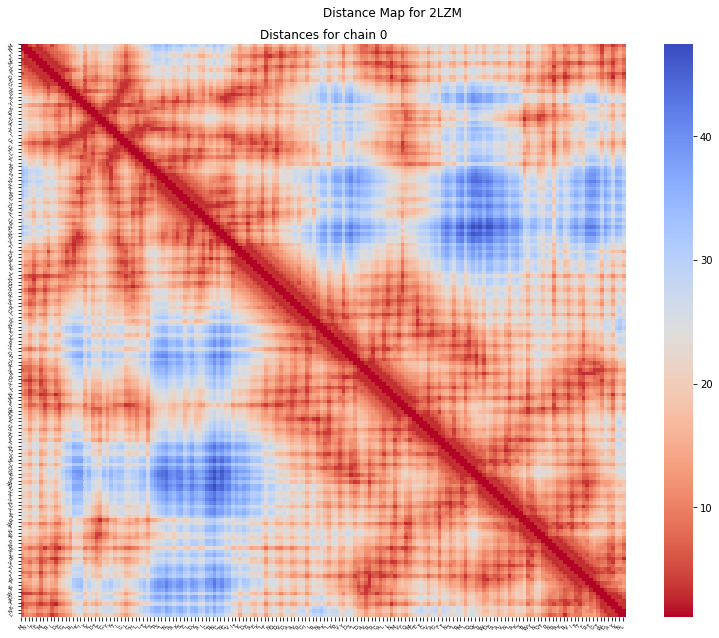

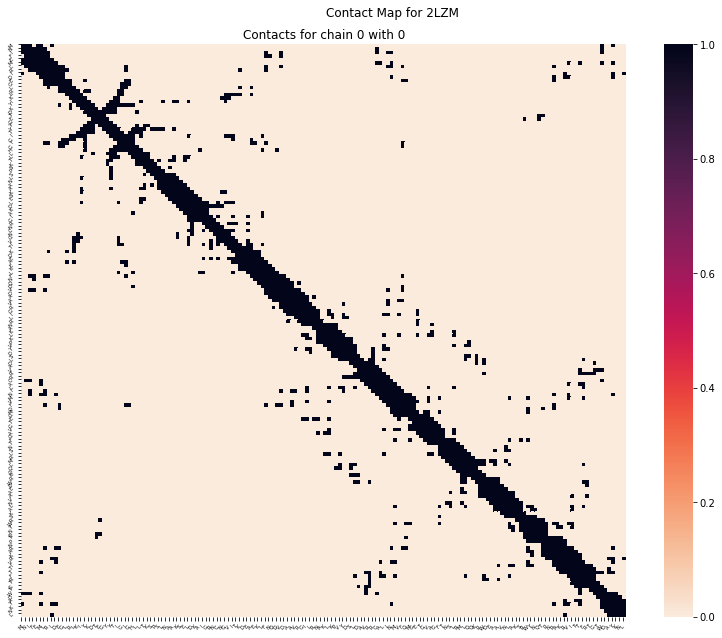

100%|█████████████████████████████████████████████████████████████████████████████| 3116/3116 [00:04<00:00, 772.26it/s]


Computing kernel matrices ...


Matrix: BENS940102: : 164it [05:01,  1.84s/it]
Matrix: CSEM940101: : 164it [05:03,  1.85s/it]
Matrix: GONG920101: : 127it [02:48,  1.20s/it]

In [ ]:
# get mutations for pdb
exp_mutations = parse_matlab_mutation_file("./data/ddg_protherm.mat", query="ddg_protherm")
sim_mutations = parse_matlab_mutation_file("./data/ddg_rosetta_single.mat", query="ddg_rosetta_single")

results = {}

# generate contactmaps, distance matrix plots
for pdb in pdbs:
    # load data from reference files
    filename = f"./pdb/{pdb.lower()}.pdb"
    save_fig = os.path.join(os.path.abspath(''), "fig/")
    ref_file = loadmat(f"./data/{pdb.upper()}.mat")
    ref_adj = convert_graph_from_matlab_file(ref_file["contact_map"])
    
    # contact map and distance matrix
    cm1 = ContactMapper(pdb_file=filename, tri_dist=True)
    cm1.plot_distance_matrix(save_fig=save_fig)
    cm1.plot_contact_map(save_fig=save_fig)
    
    # generate sub_matrices and representations ...
    pcol = ProteinCollection(cm1, pdb_ID=pdb, mutations_exp=exp_mutations, mutations_sim=sim_mutations, TESTING=False)
    pcol.plot_sub_matrices(savefig=save_fig)
   
    # extract mutations
    mut_S_exp, _, ΔΔg_exp, mut_ids_exp = parse_mutations(mutation_dict=mutations_dict_exp.get(pcol.pdb_ID), 
                                                    sequence=pcol.sequence, adjacency=ref_adj)
    mut_S_is, _, ΔΔg_is, mut_ids_is = parse_mutations(mutation_dict=mutations_dict_is.get(pcol.pdb_ID), 
                                                    sequence=pcol.sequence, adjacency=ref_adj)
    X_exp, X_is = convert_aa_sequence(mut_S_exp), convert_aa_sequence(mut_S_is)
    y_wt = np.array([0])[:, np.newaxis]
    X_wt = convert_aa_sequence([pcol.sequence])
    
    # Bayesian Scaling
    bs = BayesScaler(is_mutations=mut_ids_is, ΔΔg=pcol.ΔΔg_is, exp_mutations=mut_ids_exp, 
                        experimentally_observed_ΔΔg=pcol.ΔΔg_exp, TESTING=False, pdb_ID=pdb.upper())
    ΔΔg_exp = ΔΔg_exp[:, np.newaxis]
    ΔΔg_is_scaled = bs.transform(ΔΔg_is)[:, np.newaxis]
    bs.plot_scaling(save_fig=save_fig)
    
    # Scale y-values as done in the implementation by normalizing with mean and max
    mean_y, max_y, y_wt, ΔΔg_exp, ΔΔg_is_scaled = preprocess_observations(y_wt, ΔΔg_exp, ΔΔg_is_scaled)

    gpr = GPRegression(protein_representation=pcol, X_wt=X_wt, X_exp=X_exp, X_is=X_is, 
                         y_wt=y_wt, y_exp=ΔΔg_exp, y_is=ΔΔg_is_scaled, adjacencies=ref_adj, 
                         σ_T=bs.σ_T, y_max=max_y, y_mean=mean_y)
    opt_results, gpr_results, n_mutations = gpr.position_level_CV()
    results[pdb] = {"optimization": opt_results, "regression": gpr_results, "mutations": n_mutations}
    
    

In [ ]:
print(results)
# TODO pickle results

In [ ]:
# TODO compute Kernel matrices for each from mutations

In [ ]:
# TODO perform Regression for each

In [ ]:
# TODO scaling + regression

In [ ]:
# TODO compute correlation rho and rmse calculation